<a href="https://colab.research.google.com/github/gabrieleduardo/public-package-manager-complex-network/blob/main/Mestrado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise das redes de package managers como redes complexas

## Inicialização para processamento em GPU (cuGraph / RAPIDS)

**Atenção:** Certifique-se de estar em um ambiente com GPU ativada (Menu > Ambiente de Execução > Alterar tipo de ambiente de execução > T4 GPU).

In [1]:
# 1. Verificando a GPU e Instalando as bibliotecas RAPIDS (cuDF e cuGraph)
!nvidia-smi
!pip install cudf-cu12 cugraph-cu12 pylibcugraph-cu12 --extra-index-url=https://pypi.nvidia.com

Wed Jul 22 20:55:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import gc
import cupy

print("Limpando a memória residual da GPU...")

# Força a coleta de lixo do Python
gc.collect()

# Libera todos os blocos de memória não utilizados no pool do CuPy/RAPIDS
cupy.get_default_memory_pool().free_all_blocks()
cupy.get_default_pinned_memory_pool().free_all_blocks()

print("Memória da GPU liberada com sucesso!")

Limpando a memória residual da GPU...
Memória da GPU liberada com sucesso!


## Inicialização do grafo

In [3]:
import cudf
import cugraph
from datetime import datetime

print(f"[{datetime.now().strftime('%H:%M:%S')}] Lendo dados diretamente na Placa de Vídeo (VRAM) com cuDF...")

# cuDF é o equivalente ao Pandas, mas roda na GPU
df_vertices_gpu = cudf.read_csv('/content/data/vertices_nuget.csv')
df_arestas_gpu = cudf.read_csv('/content/data/arestas_nuget.csv')

print(f"[{datetime.now().strftime('%H:%M:%S')}] Leitura concluída. Vértices: {len(df_vertices_gpu)}, Arestas: {len(df_arestas_gpu)}")
display(df_arestas_gpu.head())

[21:01:22] Lendo dados diretamente na Placa de Vídeo (VRAM) com cuDF...
[21:01:23] Leitura concluída. Vértices: 7897000, Arestas: 31863216


,id_origem,id_destino
0,3436869,6644250
1,1969551,6656592
2,1524287,6657447
3,1331815,6669349
4,3287074,6670612


In [4]:
print(f"[{datetime.now().strftime('%H:%M:%S')}] Construindo Grafo Direcionado no cuGraph...")

# Identificando dinamicamente os nomes das colunas de origem e destino
source_col = df_arestas_gpu.columns[0]
dest_col = df_arestas_gpu.columns[1]

# Construção do grafo
G_gpu = cugraph.Graph(directed=True)
# renumber=True cuida automaticamente de mapear IDs strings/não-sequenciais para inteiros otimizados internos
G_gpu.from_cudf_edgelist(df_arestas_gpu, source=source_col, destination=dest_col, renumber=True)

print(f"[{datetime.now().strftime('%H:%M:%S')}] Grafo carregado na GPU com sucesso!")

[21:01:32] Construindo Grafo Direcionado no cuGraph...
[21:01:33] Grafo carregado na GPU com sucesso!


## Extração de indicadores da rede

### Distribuição de Graus

Distribuição de Graus (Degree Distribution): Você deve calcular o grau de entrada (in-degree, número de pacotes que dependem de um pacote v) e o grau de saída (out-degree, número de dependências que v declara). A análise desta distribuição P(k) determinará se a rede exibe a topologia livre de escala (scale-free), permitindo identificar de imediato os hubs do ecossistema que concentram um número massivo de dependentes e representam pontos críticos de falha [barabasi2012book, decan2019empirical].

[21:01:52] Calculando Graus de Entrada (In-Degree) e Saída (Out-Degree)...

=== TOP 10 PACOTES (MAIOR IN-DEGREE / MAIS DEPENDENTES) ===


,vertice_string,degree
0,newtonsoft.json-13.0.3-net8.0,168475
1,newtonsoft.json-13.0.1-net6.0,67996
2,newtonsoft.json-13.0.3-net6.0,65175
3,microsoft.extensions.configuration.abstraction...,62398
4,system.componentmodel.annotations-5.0.0-net8.0,61689
5,microsoft.extensions.dependencyinjection.abstr...,59792
6,microsoft.extensions.dependencyinjection.abstr...,59378
7,microsoft.extensions.dependencyinjection.abstr...,59365
8,microsoft.csharp-4.7.0-net8.0,58244
9,fluentvalidation-11.11.0-net8.0,53481


[21:01:52] Gerando gráficos de distribuição...


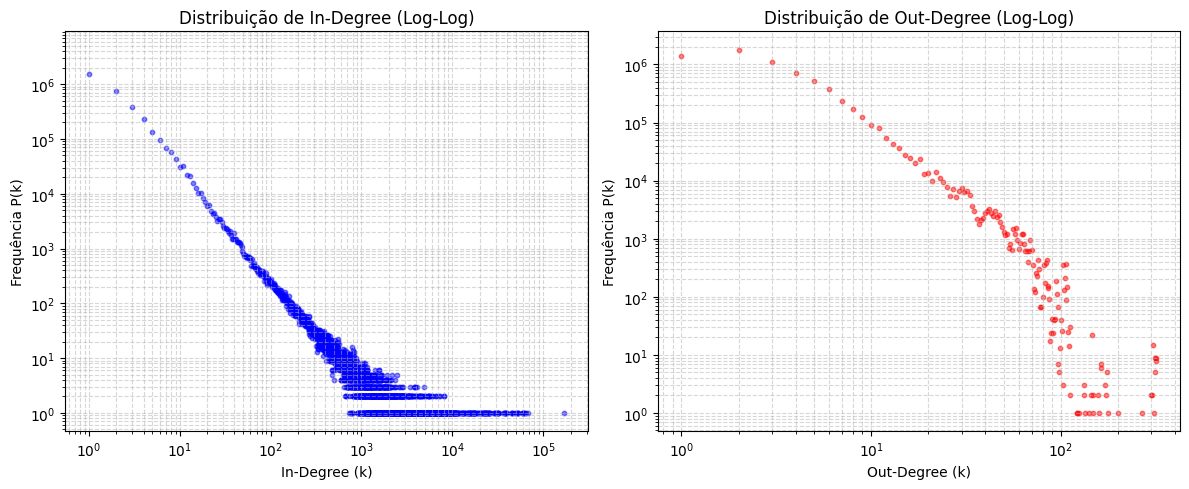

In [5]:
import matplotlib.pyplot as plt

print(f"[{datetime.now().strftime('%H:%M:%S')}] Calculando Graus de Entrada (In-Degree) e Saída (Out-Degree)...")

# 1. Calculando os graus via cuGraph
in_degree_df = G_gpu.in_degree()
out_degree_df = G_gpu.out_degree()

# 2. Identificando os maiores Hubs (Top 10 In-Degree)
# Fazer join com os nomes dos vértices para saber quais são os pacotes
top_in_degree = in_degree_df.nlargest(10, 'degree')
top_in_degree_merged = top_in_degree.merge(df_vertices_gpu, left_on='vertex', right_on='id_numerico', how='left')

print("\n=== TOP 10 PACOTES (MAIOR IN-DEGREE / MAIS DEPENDENTES) ===")
display(top_in_degree_merged[['vertice_string', 'degree']].to_pandas())

# 3. Distribuição P(k) - Agrupando as contagens de graus e trazendo para o CPU (Pandas) para plotagem
print(f"[{datetime.now().strftime('%H:%M:%S')}] Gerando gráficos de distribuição...")
in_dist = in_degree_df['degree'].value_counts().to_pandas().sort_index()
out_dist = out_degree_df['degree'].value_counts().to_pandas().sort_index()

# 4. Plotando a distribuição em escala Log-Log (típica para detectar redes scale-free)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(in_dist.index, in_dist.values, alpha=0.5, color='blue', s=10)
plt.xscale('log')
plt.yscale('log')
plt.title('Distribuição de In-Degree (Log-Log)')
plt.xlabel('In-Degree (k)')
plt.ylabel('Frequência P(k)')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.subplot(1, 2, 2)
plt.scatter(out_dist.index, out_dist.values, alpha=0.5, color='red', s=10)
plt.xscale('log')
plt.yscale('log')
plt.title('Distribuição de Out-Degree (Log-Log)')
plt.xlabel('Out-Degree (k)')
plt.ylabel('Frequência P(k)')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


### Coeficiente de Agrupamento (Clustering Coefficient)

Mede a densidade local de conexões na vizinhança de um nó, ou seja, a tendência da rede de formar triângulos fechados. Nos ecossistemas de software, um agrupamento alto sugere uma forte coesão local e a formação de blocos/nichos funcionais de bibliotecas auxiliares que trabalham em conjunto [watts1998collective].

In [9]:
print(f"[{datetime.now().strftime('%H:%M:%S')}] Calculando o Coeficiente de Agrupamento via Contagem de Triângulos...")

# O cálculo exige grafos não direcionados
G_gpu_undirected = G_gpu.to_undirected()

# 1. Obter a contagem de triângulos por nó
triangles_df = cugraph.triangle_count(G_gpu_undirected)

# 2. Obter o grau de cada nó
degree_df = G_gpu_undirected.degree()

# 3. Juntar os dois DataFrames pela coluna 'vertex'
clustering_df = triangles_df.merge(degree_df, on='vertex')

# 4. Calcular o Clustering Coefficient: C = 2 * T / (k * (k - 1))
clustering_df['clustering_coefficient'] = 0.0

# Criar uma máscara para nós com grau >= 2 para evitar divisão por zero
mask = clustering_df['degree'] >= 2

# Calcular apenas para os nós válidos
clustering_df.loc[mask, 'clustering_coefficient'] = (2.0 * clustering_df.loc[mask, 'counts']) / (clustering_df.loc[mask, 'degree'] * (clustering_df.loc[mask, 'degree'] - 1.0))

# 5. Calculando a média da rede inteira
mean_clustering = clustering_df['clustering_coefficient'].mean()

print(f"[{datetime.now().strftime('%H:%M:%S')}] Coeficiente de Agrupamento Médio: {mean_clustering:.4f}")
display(clustering_df.sort_values(by='clustering_coefficient', ascending=False).head(10))

[21:05:12] Calculando o Coeficiente de Agrupamento via Contagem de Triângulos...
[21:05:16] Coeficiente de Agrupamento Médio: 0.0273


,vertex,counts,degree,clustering_coefficient
1202637,4865768,36,18,0.235294
1563373,268724,21,14,0.230769
1564530,196471,21,14,0.230769
1589242,714738,21,14,0.230769
1597234,950599,21,14,0.230769
1627133,1459841,21,14,0.230769
1636455,1780607,21,14,0.230769
1664752,2496968,21,14,0.230769
1665782,2464467,21,14,0.230769
1674540,2638048,21,14,0.230769


### Extração dos componentes fracamente conectados (WCC)

In [10]:
print(f"[{datetime.now().strftime('%H:%M:%S')}] Extraindo Componentes Fracamente Conectadas (WCC)...")

# WCC no cuGraph requer que o grafo seja não-direcionado
G_gpu_undirected = G_gpu.to_undirected()
wcc_df = cugraph.weakly_connected_components(G_gpu_undirected)

# Contando o tamanho de cada componente para achar a Giant Component
wcc_counts = wcc_df['labels'].value_counts()
giant_label = wcc_counts.index[0]
giant_size = wcc_counts.iloc[0]

print(f"[{datetime.now().strftime('%H:%M:%S')}] Total de Componentes (WCC): {len(wcc_counts)}")
print(f"[{datetime.now().strftime('%H:%M:%S')}] Tamanho da Giant Component: {giant_size} nós")

[21:05:29] Extraindo Componentes Fracamente Conectadas (WCC)...
[21:05:32] Total de Componentes (WCC): 41495
[21:05:32] Tamanho da Giant Component: 2297048 nós


### Calcular Caminho Mínimo e Diâmetro via amostragem

O caminho mínimo médio caracteriza a distância típica entre pares de nós, enquanto o diâmetro mede a maior distância possível na rede. Essas propriedades servirão para atestar se a rede possui a característica de "mundo pequeno" (small-world). Caminhos curtos indicam que vulnerabilidades ou depreciações de código (como no caso do pacote left-pad) podem se propagar rapidamente e causar falhas em cascata massivas [strogatz2001exploring, schlueter2016kik].

In [11]:
import random
import gc
import cupy

print(f"[{datetime.now().strftime('%H:%M:%S')}] Aproximando Caminho Mínimo e Diâmetro via Amostragem...")

# Selecionando apenas nós que pertencem à Giant Component (LWCC)
lwcc_nodes = wcc_df[wcc_df['labels'] == giant_label]['vertex'].to_pandas().tolist()

# Liberando a memória da tabela WCC da GPU antes de rodar os caminhos mínimos
del wcc_df
gc.collect()
cupy.get_default_memory_pool().free_all_blocks()

# Ajustando para 100 para garantir que rode com folga na memória residual
AMOSTRA_TAMANHO = 100
sample_nodes = random.sample(lwcc_nodes, min(AMOSTRA_TAMANHO, len(lwcc_nodes)))

max_distances = []
sum_distances = []
count_paths = []

for i, node in enumerate(sample_nodes):
    # BFS (Breadth-First Search) é usado para caminhos mínimos em grafos não-ponderados
    distances = cugraph.bfs(G_gpu, node)

    # Filtrar caminhos inalcançáveis (distâncias muito grandes)
    valid_paths = distances[distances['distance'] < 1e9]['distance']

    if len(valid_paths) > 0:
        max_distances.append(valid_paths.max())
        sum_distances.append(valid_paths.sum())
        count_paths.append(len(valid_paths))

    # Limpeza explícita profunda da memória da GPU a cada iteração
    del distances
    del valid_paths
    gc.collect()
    cupy.get_default_memory_pool().free_all_blocks()

    if (i + 1) % 25 == 0:
        print(f"Processados {i + 1}/{len(sample_nodes)} nós da amostra...")

aprox_diameter = max(max_distances)
aprox_avg_path = sum(sum_distances) / sum(count_paths)

print(f"\n=== RESULTADOS APROXIMADOS (Baseado em {len(sample_nodes)} nós) ===")
print(f"Diâmetro Estimado: {aprox_diameter}")
print(f"Caminho Mínimo Médio Estimado: {aprox_avg_path:.4f}")

[21:05:40] Aproximando Caminho Mínimo e Diâmetro via Amostragem...
Processados 25/100 nós da amostra...
Processados 50/100 nós da amostra...
Processados 75/100 nós da amostra...
Processados 100/100 nós da amostra...

=== RESULTADOS APROXIMADOS (Baseado em 100 nós) ===
Diâmetro Estimado: 11
Caminho Mínimo Médio Estimado: 3.1635


### Detectar Comunidades de Louvain

In [12]:
print(f"[{datetime.now().strftime('%H:%M:%S')}] Detectando Comunidades com Louvain (GPU)...")

# Louvain requer que o grafo seja não-direcionado
G_undirected_gpu = cugraph.Graph(directed=False)
G_undirected_gpu.from_cudf_edgelist(df_arestas_gpu, source=source_col, destination=dest_col, renumber=True)

# Rodando Louvain
parts, modularity = cugraph.louvain(G_undirected_gpu)

num_communities = parts['partition'].nunique()
print(f"[{datetime.now().strftime('%H:%M:%S')}] Número de comunidades detectadas: {num_communities}")
print(f"[{datetime.now().strftime('%H:%M:%S')}] Modularidade (Q): {modularity:.4f}")

[21:06:07] Detectando Comunidades com Louvain (GPU)...


RuntimeError: non-success value returned from cugraph_graph_create_with_times_sg(): CUGRAPH_UNKNOWN_ERROR std::bad_alloc: out_of_memory: CUDA error (failed to allocate 509810776 bytes) at: /__w/rmm/rmm/cpp/include/rmm/mr/cuda_memory_resource.hpp:51: cudaErrorMemoryAllocation out of memory